<a href="https://colab.research.google.com/github/polaya813/polaya813/blob/main/Ejercicio_clase_Lecci%C3%B3n_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
# 1. Definir la url desde la que se leerá el archivo CSV:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
# 2.Leer el archivo CSV desde la URL y cargarlo en un DataFrame:
df_titanic_original = pd.read_csv(url)
# 3. Almacenar el DataFrame en un archivo CSV:
df_titanic_original.to_csv("titanic.csv", index=False)

Eliminación de Variables a descartar: PassengerId	❌ Eliminar	Identificador sin valor analítico	No aporta información estadística ni predictiva. Solo sirve como índice.

Name	❌ Eliminar	Texto no estructurado	Contiene títulos pero requiere ingeniería de características. No se usa en EDA básico ni en pipelines simples.

Ticket	❌ Eliminar	Formato inconsistente	Numeración caótica; aporta poco valor y agrega ruido al análisis.

Cabin	❌ Eliminar	Demasiados nulos	Más de 70% de valores faltantes; altamente incompleta, difícil de utilizar sin imputaciones avanzadas.

In [2]:
# Crear un lista con las columnas a eliminar según la selección KDD
cols_a_borrar = ["PassengerId", "Name", "Ticket", "Cabin"]

# Crear un nuevo dataframe que contendrá una copia del dataframe original pero SIN las columnas eliminadas.
df_titanic_limpio = df_titanic_original.drop(columns=cols_a_borrar)

# Verificación final
print("Columnas eliminadas:", cols_a_borrar)
print("Columnas restantes:", df_titanic_limpio.columns.tolist())

Columnas eliminadas: ['PassengerId', 'Name', 'Ticket', 'Cabin']
Columnas restantes: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


Detección y Tratamiento de Datos Faltantes.

In [4]:
# Identificar y Cuantificar:

# print(df.isnull().sum()): Retorna un resumen conciso, mostrando el número total de valores nulos para cada columna del dataframe.

# print(df.isna().any(axis=1).sum()): Retorna cuántas filas están "contaminadas" con al menos un nulo.

In [5]:
print("Conteo de faltantes por columna:")
print(df_titanic_limpio.isnull().sum())

print("\nPorcentaje de faltantes por columna:")
print(df_titanic_limpio.isnull().sum() / len(df_titanic_limpio) * 100)

print("\nConteo de filas con al menos un valor faltante:")
print(df_titanic_limpio.isna().any(axis=1).sum())

Conteo de faltantes por columna:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Porcentaje de faltantes por columna:
Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Embarked     0.224467
dtype: float64

Conteo de filas con al menos un valor faltante:
179


Tratamiento de Datos Faltantes:

- Variables o Columnas de tipo numéricas: Imputar con la mediana

- Variables o Columnas de tipo categóricas: Imputar con la moda

Detección y Tratamiento de Datos Duplicados

Identificar la presencia de filas duplicadas cuantificarlos y eliminarlos

In [6]:
# 1. Ver cuántos duplicados hay
df_titanic_limpio.duplicated().sum()

# 2. Ver los registros duplicados (opcional, para inspección)
# df_titanic_limpio[df_titanic_limpio.duplicated()]

# 3. Eliminar duplicados manteniendo la primera aparición
df_titanic_limpio = df_titanic_limpio.drop_duplicates()

# 4. Confirmar que ya no existen duplicados
df_titanic_limpio.duplicated().sum()

np.int64(0)

Detección y Tratamiento de Valores Atípicos (Outliers)


Identificar valores extremos mediante el método IQR en las columnas que son de tipo númerico y tratarlos mediante la técnica de winsorización, reemplazándolos por los límites inferior y superior permitidos según el rango IQR.

Visualización de Outliers.

Generar un boxplot por cada columna numérica para dentificar la posible presencia de outliers:

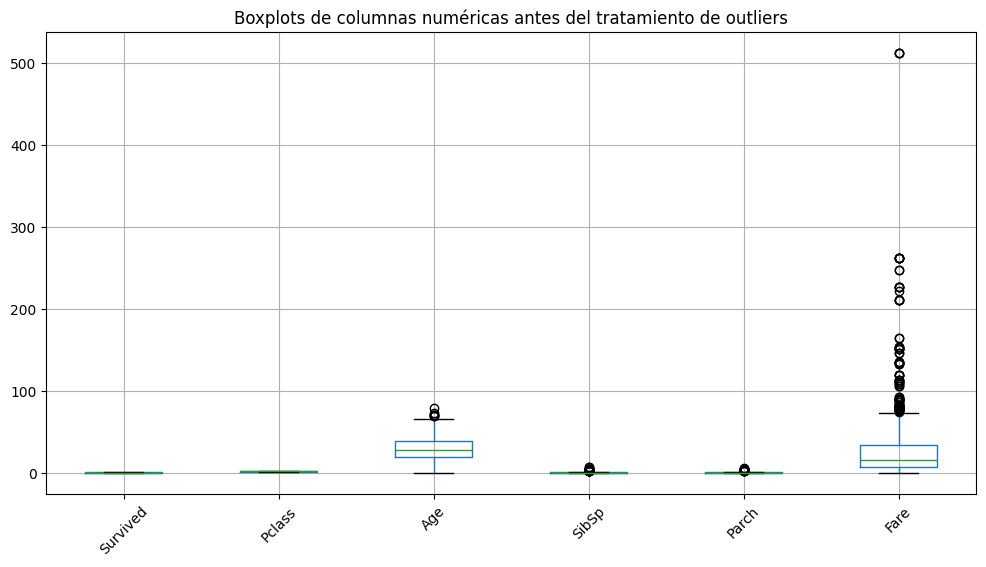

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar columnas numéricas
numeric_cols = df_titanic_limpio.select_dtypes(include=['int64', 'float64']).columns

# Generar un boxplot por columna numérica
plt.figure(figsize=(12, 6))
df_titanic_limpio[numeric_cols].boxplot()
plt.title("Boxplots de columnas numéricas antes del tratamiento de outliers")
plt.xticks(rotation=45)
plt.show()

Tratamiento de Outliers

Identificación de outliers

Se calcula Q1 (percentil 25) y Q3 (percentil 75).

Se obtiene el rango IQR = Q3 – Q1.

Se definen los límites:

Límite inferior = Q1 − 1.5 × IQR

Límite superior = Q3 + 1.5 × IQR

Cualquier valor fuera de estos límites se considera outlier.

Este proceso se realiza sobre cada una de las columnas.

In [8]:
outliers_info = {}

numeric_cols = df_titanic_limpio.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df_titanic_limpio[col].quantile(0.25)
    Q3 = df_titanic_limpio[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = df_titanic_limpio[(df_titanic_limpio[col] < lim_inf) | (df_titanic_limpio[col] > lim_sup)]

    outliers_info[col] = {
        "outliers_totales": len(outliers),
        "lim_inferior": lim_inf,
        "lim_superior": lim_sup
    }

Tratamiento (winsorización) de Outliers

Los valores menores al límite inferior se reemplazaron por el límite inferior.

Los valores mayores al límite superior se reemplazaron por el límite superior.

/tmp/ipykernel_8450/1422763440.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_titanic_limpio[col] = df_titanic_limpio[col].clip(lower=lim_inf, upper=lim_sup)
/tmp/ipykernel_8450/1422763440.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_titanic_limpio[col] = df_titanic_limpio[col].clip(lower=lim_inf, upper=lim_sup)
/tmp/ipykernel_8450/1422763440.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

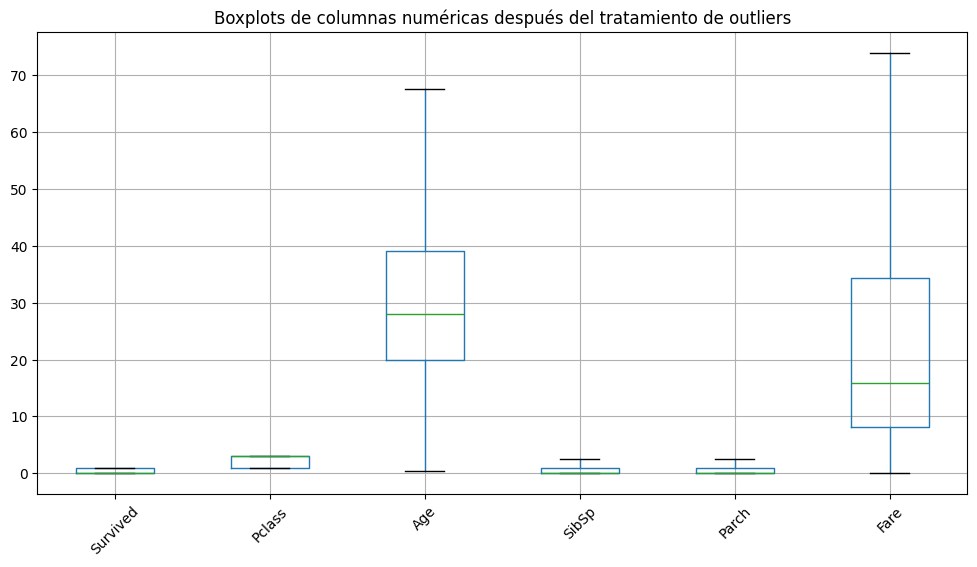

In [9]:
numeric_cols = df_titanic_limpio.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df_titanic_limpio[col].quantile(0.25)
    Q3 = df_titanic_limpio[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    df_titanic_limpio[col] = df_titanic_limpio[col].clip(lower=lim_inf, upper=lim_sup)

# Generar nuevamente la visualización de Outliers para confirmar la aplicación del ajuste realizado:
# Generar un boxplot por columna numérica
plt.figure(figsize=(12, 6))
df_titanic_limpio[numeric_cols].boxplot()
plt.title("Boxplots de columnas numéricas después del tratamiento de outliers")
plt.xticks(rotation=45)
plt.show()